# Predict Neutralization for New Viral Sequences

Uses the GLR model from `GNL_clean.ipynb` to predict neutralization values
for one or more new viral sequences not in the training matrix.

**Files read from `../processed-data/`:**
alignment-based PCA basis (`evt_O.txt`, `evl_O.txt`, `idx_ply_oh.txt`,
`subtract_projected_O.txt`, `std_projected_O.txt`),
alignment-free PCA basis (`evt_O_w_features.txt`,
`subtract_projected_F_O.txt`, `std_projected_F_O.txt`),
and the full training data files used by `GNL_clean.ipynb`.

**Input FASTA requirements:**
- The FASTA must contain the **HXB2 reference sequence** (header must match `HXB2`).
- Query sequences must already be **aligned with HXB2** (same alignment).
- Only positions that are **non-gap in HXB2** are retained for prediction.
- Alignment-free features are optional (30 columns matching `mat_features.txt`).
  If not provided, mean values (zeros after normalization) are substituted.

**Output:** one CSV per query sequence in `../output/`, columns: `antibody`, `predicted_{DATA_TYPE}`.

> **Prerequisite:** re-run `process.ipynb` once to generate the normalization parameter files
> (`subtract_projected_O.txt`, `std_projected_O.txt`,
> `subtract_projected_F_O.txt`, `std_projected_F_O.txt`) in `../processed-data/`.


In [1]:
using DelimitedFiles, StatsBase, Random, Statistics, Distributions, LinearAlgebra, Clustering, Printf, CSV, DataFrames

DIR_SOURCE_CODE = "../src"
include("$(DIR_SOURCE_CODE)/tools_imputation_minimum.jl");

## Configuration

Edit the paths and parameters below before running.


In [2]:
# ── Directories ──────────────────────────────────────────────────────────
DIR_IN     = "../processed-data"   # preprocessed training data
DIR_PARAMS = "../output"           # GLR parameter cache (parameters-${file_key}_${DATA_TYPE}.txt)
DATA_KEY = "used-for-training" # "not-used-for-training" or "used-for-training"
DIR_OUT = "../prediction-output/$(DATA_KEY)_LowApp"           # predictions are written here
DIR_RAW = "../raw-data"

# ── Training run to match ─────────────────────────────────────────────────
file_key  = "test"    # must match the run used in GNL_clean.ipynb
DATA_TYPE = "IC50"    # "IC50" | "IC80" | "HillCoeff" | "IIP"

# ── Input: aligned FASTA ─────────────────────────────────────────────────
# Must contain HXB2 (header matching 'HXB2') + one or more query sequences,
# all co-aligned. Only HXB2 non-gap positions are used for prediction.
DIR_NAME_NEW_DATA = "../test-data"
fname_new_fasta = "$(DIR_NAME_NEW_DATA)/$(DATA_KEY).fasta" 
fname_new_accession = "$(DIR_NAME_NEW_DATA)/$(DATA_KEY).accession"

# ── Input: alignment-free features (optional) ────────────────────────────
# Plain-text file with one row per new sequence, 30 columns matching mat_features.txt.
# Set to `nothing` to use mean values (zeros) instead.
fname_new_features = nothing  # e.g., "$(DIR_NAME_NEW_DATA)/new_features.txt"

# ── GLR hyperparameters (match GNL_clean.ipynb defaults) ─────────────────
λ1_eff    = 10
λ2_eff    = 5
k_max     = 100
n_max_eigen = Int(floor(0.5 * k_max))
d_scale   = 0.5
d_eff_max = 100
flag_eff_GLR = false

num_minimum_num_ic50_each_abs = 1
num_minimum_num_ic50_each_vrs = 10

# ── Low-rank approximation ranks (matches GNL_clean.ipynb) ──────────────
rank_set = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400];

## Step 1: Project New Sequence(s)

Load the PCA bases and normalization parameters, then project each new sequence
into the same merged feature space used during training.


In [3]:
# ── Alignment-based PCA basis ────────────────────────────────────────────
evl_aln = vec(readdlm("$(DIR_IN)/evl_O.txt"))
evt_aln = readdlm("$(DIR_IN)/evt_O.txt")
rank_PCA = count(evl_aln .> 1e-5)
# Top eigenvectors in descending order (same as process.ipynb Cell 11)
PCA_space_aln = evt_aln[:, end:-1:end+1-rank_PCA]

subtract_projected = readdlm("$(DIR_IN)/subtract_projected_O.txt")[1]
std_projected      = readdlm("$(DIR_IN)/std_projected_O.txt")[1]

# idx_ply_oh selects polymorphic one-hot columns (written as "true"/"false")
idx_ply_oh = vec(parse.(Bool, readdlm("$(DIR_IN)/idx_ply_oh.txt", String)))

q = length(Alpha_set_O)

# ── Alignment-free PCA basis ──────────────────────────────────────────────
evt_F = readdlm("$(DIR_IN)/evt_O_w_features.txt")
# Reverse columns: top eigenvectors first (same as process.ipynb Cell 15)
PCA_space_F = evt_F[:, end:-1:1]
n_var_F = size(PCA_space_F, 2)

subtract_projected_F = readdlm("$(DIR_IN)/subtract_projected_F_O.txt")[1]
std_projected_F      = readdlm("$(DIR_IN)/std_projected_F_O.txt")[1]

@printf("rank_PCA=%d  |  alignment-free components=%d\n", rank_PCA, n_var_F);

rank_PCA=2109  |  alignment-free components=30


In [4]:
# Parse the input FASTA (must contain HXB2 + query sequences, all co-aligned)
(all_msa, all_headers, _) = read_fastafile(fname_new_fasta)
accession_new_list = readdlm(fname_new_accession)[:, 1]

# Identify HXB2 and derive non-gap site mask (mirrors process.ipynb Cell 10)
idx_HXB2_in = [!isnothing(match(r"HXB2", string(x))) for x in all_headers]
@assert count(idx_HXB2_in) == 1 "Input FASTA must contain exactly one HXB2 sequence."
i_HXB2_in  = findall(idx_HXB2_in)[1]
idx_nongap = all_msa[i_HXB2_in] .!= "-"
L = count(idx_nongap)

# Separate query sequences from HXB2
new_msa     = all_msa[.!idx_HXB2_in]
new_headers = all_headers[.!idx_HXB2_in]
n_new = length(new_msa)

@assert n_new == length(accession_new_list) # ensure the entries of FASTA and accession file match
@printf("Loaded %d query sequence(s)  |  HXB2 non-gap positions: %d\n", n_new, L)

# Load alignment-free features for new sequences (if provided)
use_new_features = !isnothing(fname_new_features) && isfile(fname_new_features)
new_features_raw = use_new_features ? readdlm(fname_new_features) : nothing
if use_new_features
    @printf("Alignment-free features loaded: %d rows × %d cols\n", size(new_features_raw)...)
else
    println("No alignment-free features provided — using mean values (zeros after normalization).")
end

# Project each query sequence into the merged feature space
n_var_temp = rank_PCA + 1   # alignment-based components + intercept
n_min      = n_var_F        # number of alignment-free components
n_merged   = n_var_temp + n_var_F
merged_features_new = zeros(n_merged, n_new)

for s in 1:n_new
    seq = new_msa[s]
    @assert length(seq) == length(all_msa[i_HXB2_in]) (
        "Query sequence $s has length $(length(seq)) but HXB2 has length $(length(all_msa[i_HXB2_in])). "
        * "All sequences in the FASTA must be co-aligned.")

    # ── Alignment-based projection ────────────────────────────────────────
    seq_cut = seq[idx_nongap]
    # Replace unknown amino acids with gap symbol
    seq_act = [haskey(aa2num_O, x) ? aa2num_O[x] : aa2num_O["-"] for x in seq_cut]
    one_hot     = one_hot_encode(reshape(seq_act, 1, L), q, 1, L)  # (1 × q*L)
    one_hot_ply = one_hot[:, idx_ply_oh]                            # (1 × 8283)
    raw_proj    = PCA_space_aln' * one_hot_ply'                     # (rank_PCA × 1)
    norm_proj   = (1.0 / std_projected) * (raw_proj .- subtract_projected)
    proj_aln    = vcat([1.0], vec(norm_proj))                       # prepend intercept

    # ── Alignment-free projection ─────────────────────────────────────────
    if use_new_features
        x_F      = vec(new_features_raw[s, :])
        raw_F    = PCA_space_F' * x_F
        proj_F   = (1.0 / std_projected_F) * (raw_F .- subtract_projected_F)
    else
        proj_F = zeros(n_var_F)   # mean = 0 after normalization
    end

    # ── Merge (same interleaving as GNL_clean.ipynb Cell 8) ──────────────
    merged = zeros(n_merged)
    for k in 1:n_min
        merged[2*(k-1)+1] = proj_F[k]    # alignment-free k
        merged[2*k]        = proj_aln[k]  # alignment-based k (k=1 is intercept)
    end
    for k in (n_min+1):n_var_temp
        merged[k + n_min] = proj_aln[k]
    end
    merged_features_new[:, s] = merged
end
@printf("Projected %d query sequence(s) → feature vectors of length %d\n", n_new, n_merged);

Loaded 4 query sequence(s)  |  HXB2 non-gap positions: 857
No alignment-free features provided — using mean values (zeros after normalization).
Projected 4 query sequence(s) → feature vectors of length 2140


## Step 2: Load Training Data

Load and filter the training matrix using all observed values (no withholding).


In [5]:
# Load neutralization matrix
IC50_single_w_seq = if DATA_TYPE == "IC50"
    readdlm("$(DIR_IN)/IC50_single_w_seq_O.txt")
elseif DATA_TYPE == "IC80"
    readdlm("$(DIR_IN)/IC80_single_w_seq_O.txt")
elseif DATA_TYPE == "HillCoeff"
    readdlm("$(DIR_IN)/HillCoeff_w_seq_O.txt")
elseif DATA_TYPE == "IIP"
    readdlm("$(DIR_IN)/IIP_w_seq_O.txt")
end

# Load antibody / virus identifiers
antibody_unique_catnap_single_abs_temp = readdlm("$(DIR_IN)/antibody_unique_catnap_single_abs_O.txt")
antibody_unique_catnap_single_abs = [join(antibody_unique_catnap_single_abs_temp[i, :]) for i in 1:size(antibody_unique_catnap_single_abs_temp, 1)]
virus_unique_catnap_filtered = readdlm("$(DIR_IN)/virus_unique_catnap_filtered_O.txt")

# Load training PCA features and build merged feature matrix
projected_seq_PCA_train   = readdlm("$(DIR_IN)/projected_seq_PCA_O.txt")
projected_seq_PCA_F_train = readdlm("$(DIR_IN)/projected_seq_PCA_O_w_features.txt")

nv_temp, nv_F_temp = size(projected_seq_PCA_train, 1), size(projected_seq_PCA_F_train, 1)
n_min_train = nv_F_temp
projected_seq_PCA_merged = zeros(nv_temp + nv_F_temp, size(projected_seq_PCA_train, 2))
for k in 1:n_min_train
    projected_seq_PCA_merged[(2*(k-1)+1), :] = projected_seq_PCA_F_train[k, :]
    projected_seq_PCA_merged[(  2 * k  ), :] = projected_seq_PCA_train[k, :]
end
for k in (n_min_train+1):nv_temp
    projected_seq_PCA_merged[k + n_min_train, :] = projected_seq_PCA_train[k, :]
end

# Filter to antibodies/viruses with enough data
(idx_enough_abs, idx_enough_vrs) = get_idx_to_exclude(
    IC50_single_w_seq, num_minimum_num_ic50_each_abs, num_minimum_num_ic50_each_vrs)

antibody_in_process      = antibody_unique_catnap_single_abs[idx_enough_abs]
virus_in_process         = virus_unique_catnap_filtered[idx_enough_vrs]
IC50_in_process          = Matrix{Any}(copy(IC50_single_w_seq[idx_enough_abs, idx_enough_vrs]))
projected_seq_in_process = copy(projected_seq_PCA_merged)[:, idx_enough_vrs]
N_A, M = size(IC50_in_process)
@printf("Training: %d antibodies × %d viruses\n", N_A, M);

Update abs = 0, Update vrs = 0
Training: 806 antibodies × 1145 viruses


## Step 3: GLR Parameters (Load or Train)

If `output/parameters-${file_key}_${DATA_TYPE}.txt` exists, saved parameters are loaded
and GLR training is skipped. Otherwise, clustering and GLR training run and
results are saved for future reuse.

In [6]:
# ── Parameter file paths ─────────────────────────────────────────────────
fname_sentinel    = "$(DIR_PARAMS)/parameters-$(file_key)_$(DATA_TYPE).txt"
fname_deff        = "$(DIR_PARAMS)/parameters-$(file_key)_$(DATA_TYPE)_deff.txt"
fname_theta_sizes = "$(DIR_PARAMS)/parameters-$(file_key)_$(DATA_TYPE)_theta_sizes.txt"
fname_theta_flat  = "$(DIR_PARAMS)/parameters-$(file_key)_$(DATA_TYPE)_theta_flat.txt"
fname_class_sizes = "$(DIR_PARAMS)/parameters-$(file_key)_$(DATA_TYPE)_class_sizes.txt"
fname_class_flat  = "$(DIR_PARAMS)/parameters-$(file_key)_$(DATA_TYPE)_class_flat.txt"

if isfile(fname_sentinel)
    println("Loading saved GLR parameters from $(DIR_PARAMS)/")

    d_eff_set = Int.(vec(readdlm(fname_deff)))

    theta_sizes = Int.(vec(readdlm(fname_theta_sizes)))
    theta_flat  = vec(readdlm(fname_theta_flat))
    θ_set_efficient = []
    offset = 0
    for sz in theta_sizes
        push!(θ_set_efficient, theta_flat[offset+1:offset+sz])
        offset += sz
    end

    class_sizes = Int.(vec(readdlm(fname_class_sizes)))
    class_flat  = Int.(vec(readdlm(fname_class_flat)))
    set_of_indices_each_class = []
    offset = 0
    for sz in class_sizes
        push!(set_of_indices_each_class, class_flat[offset+1:offset+sz])
        offset += sz
    end

    println("Parameters loaded ($(k_max) groups).")
else
    println("No saved parameters found — running GLR training.")

    # Build antibody similarity matrix and cluster
    (cosign_abs_similarity, similarity_matrix) = compute_antibody_similarity_matrix(IC50_in_process, N_A, M)
    labels = spectral_clustering(similarity_matrix, k_max, n_max_eigen)

    set_of_num_each_class     = [count(labels .== i) for i in 1:k_max]
    idx_sort_class_number     = sortperm(set_of_num_each_class)
    set_of_indices_each_class = [collect(1:N_A)[labels .== i] for i in idx_sort_class_number]

    # Fit GLR parameters
    d_eff_set       = []
    θ_set_efficient = []

    for i in 1:k_max
        indicies_temp = set_of_indices_each_class[i]

        if length(indicies_temp) == 1
            n_abs = indicies_temp[1]
            idx   = string.(IC50_in_process[n_abs, :]) .!= "NaN"
            d_eff = minimum([Int(floor(count(idx) * d_scale)), d_eff_max])
            if d_eff < 2; d_eff = 2; end
            if count(idx) > 0
                X      = projected_seq_in_process[1:d_eff, idx]'
                θ_temp = (X' * X + λ1_eff * I) \ (float.(projected_seq_in_process[1:d_eff, idx]) * float.(IC50_in_process[n_abs, idx]))
                push!(θ_set_efficient, copy(θ_temp))
            else
                push!(θ_set_efficient, zeros(d_eff))
            end
            push!(d_eff_set, d_eff)
        else
            num_abs_in_a_class = length(indicies_temp)
            idx_eff = [false for _ in 1:M]
            for n in 1:num_abs_in_a_class
                idx_eff = idx_eff .|| (string.(IC50_in_process[indicies_temp[n], :]) .!= "NaN")
            end
            d_eff = minimum([Int(floor(count(idx_eff) * d_scale)), d_eff_max])
            if d_eff < 2; d_eff = 2; end

            Xi  = zeros(num_abs_in_a_class * d_eff, num_abs_in_a_class * d_eff)
            psi = zeros(num_abs_in_a_class * d_eff)
            for n in 1:num_abs_in_a_class
                n_abs = indicies_temp[n]
                idx   = string.(IC50_in_process[n_abs, :]) .!= "NaN"
                X      = projected_seq_in_process[1:d_eff, idx]'
                mat_xi = X' * X + λ1_eff * I
                Xi[km(n,1,d_eff):km(n,d_eff,d_eff), km(n,1,d_eff):km(n,d_eff,d_eff)] = copy(mat_xi)
                psi[km(n,1,d_eff):km(n,d_eff,d_eff)] = float.(projected_seq_in_process[1:d_eff, idx]) * float.(IC50_in_process[n_abs, idx])
            end
            idx_to_look = [j ∈ indicies_temp for j in 1:N_A]
            W_min   = cosign_abs_similarity[idx_to_look, idx_to_look]
            Lap_min = compute_laplacian(W_min)
            @time θ_temp = (Xi + kron(λ2_eff * Lap_min, diagm(0 => ones(d_eff)))) \ psi
            push!(θ_set_efficient, copy(θ_temp))
            push!(d_eff_set, d_eff)
        end
    end

    # Save all parameter files; write sentinel last to mark completion
    mkpath(DIR_PARAMS)
    writedlm(fname_deff, d_eff_set)
    writedlm(fname_theta_sizes, [length(θ) for θ in θ_set_efficient])
    writedlm(fname_theta_flat, reduce(vcat, θ_set_efficient))
    writedlm(fname_class_sizes, [length(c) for c in set_of_indices_each_class])
    writedlm(fname_class_flat, reduce(vcat, set_of_indices_each_class))
    writedlm(fname_sentinel, ["parameters saved"])
    println("GLR training complete. Parameters saved to $(DIR_PARAMS)/")
end

Loading saved GLR parameters from ../output/
Parameters loaded (100 groups).


## Step 4: Predict and Export

Apply the fitted GLR to each new sequence's feature vector and export predictions.


In [7]:
# --- this is adhoc need to be cleaned up --- #
IC50_single_w_seq_O_temp = readdlm("../output/IC50_single_w_seq_O.txt")
virus_name_full_temp = readdlm("../output/virus_unique_catnap_filtered_O.txt")[:, 1];
# ------------------------------------------- #

absID2class_orderID = build_absID2class_orderID(set_of_indices_each_class, k_max)

# Step 1-3: build full imputed training matrix (N_A × M)
# Observed entries are kept intact; missing entries filled with GLR estimates.
ic50_imputed_train = apply_glr_imputation(
    IC50_in_process, projected_seq_in_process,
    θ_set_efficient, d_eff_set, absID2class_orderID, N_A)
ic50_imputed_train_float = float.(ic50_imputed_train)  # (N_A × M)

for s in 1:n_new
    x_new = merged_features_new[:, s]

    # Step 4: GLR prediction for the new sequence (independent of training matrix)
    predicted_glr = zeros(N_A)
    for n in 1:N_A
        id_class_n, id_order_n = absID2class_orderID[n]
        d_eff = d_eff_set[id_class_n]
        θ_n   = θ_set_efficient[id_class_n][km(id_order_n, 1, d_eff):km(id_order_n, d_eff, d_eff)]
        predicted_glr[n] = x_new[1:d_eff]' * θ_n
    end

    # Step 5-7: append new column, apply low-rank SVD, extract updated prediction
    ic50_extended = hcat(ic50_imputed_train_float, predicted_glr)   # N_A × (M+1)
    (_, σ_ext, U_ext, V_ext, min_ic50_ext) = making_lowrank_mat_return_UV(ic50_extended, rank_set[1])
    cumsum_ext = cumsum(σ_ext .^ 2) ./ sum(σ_ext .^ 2)
    rank_opt   = collect(1:length(cumsum_ext))[cumsum_ext .>= 0.95][1]
    L_approx   = making_lowrank_mat_given_UV(σ_ext, rank_opt, U_ext, V_ext, min_ic50_ext)
    predicted  = L_approx[:, end]   # last column = low-rank-updated prediction

    label = accession_new_list[s]
    idx   = virus_name_full_temp .== label
    true_values = vec(copy(IC50_single_w_seq_O_temp[:, idx]))

    df = DataFrame(antibody = antibody_in_process)
    df[:, Symbol("true_$(DATA_TYPE)")]      = true_values
    df[:, Symbol("predicted_$(DATA_TYPE)")] = predicted

    fname_out = @sprintf("%s/predicted_%s_%s_%s.csv", DIR_OUT, DATA_TYPE, file_key, label)
    CSV.write(fname_out, df)
    @printf("[%d/%d] rank_opt=%d  Saved → %s\n", s, n_new, rank_opt, fname_out)
end

[1/4] rank_opt=25  Saved → ../prediction-output/used-for-training_LowApp/predicted_IC50_test_ZENV92_1008_8.csv
[2/4] rank_opt=25  Saved → ../prediction-output/used-for-training_LowApp/predicted_IC50_test_98CN009.csv
[3/4] rank_opt=25  Saved → ../prediction-output/used-for-training_LowApp/predicted_IC50_test_V704_0662_190SN.csv
[4/4] rank_opt=25  Saved → ../prediction-output/used-for-training_LowApp/predicted_IC50_test_CNE58.csv


## Low-rank approximation

The GLR-predicted column for the new sequence is appended to the fully-imputed training matrix
(`N_abs × (M+1)`). The optimal-rank SVD (≥95% cumulative variance, same logic as `GNL_clean.ipynb`)
is then applied to the extended matrix. The final prediction is the last column of the
low-rank reconstruction.


In [8]:
accession_not_used = readdlm("../test-data/not-used-for-training.accession")[:,1]
accession_used = readdlm("../test-data/used-for-training.accession")[:,1];

In [11]:
using Plots, Measures
# Data that are used for train the model, but learning the values without showing the neutralization values at all. 
DATA_KEY = "used-for-training"
DIR_OUT = "../prediction-output/$(DATA_KEY)_LowApp"
p1 = plot(legend=:false, foreground_color_legend = nothing)
true_vec, predited_vec = [], []
for s in accession_used
    fname_in = @sprintf("%s/predicted_%s_%s_%s.csv", DIR_OUT, DATA_TYPE, file_key, s)
    csv_in = CSV.read(fname_in, DataFrame)
    idx = .!isnan.(csv_in.true_IC50) 
    if(count(idx)>0)
        scatter!(p1, csv_in.true_IC50[idx], csv_in.predicted_IC50[idx], color = RGB(rand(), rand(), rand()), markerstrokecolor=:auto, markeralpha=0.5,)
        push!(true_vec, copy(csv_in.true_IC50[idx]))
        push!(predited_vec, copy(csv_in.predicted_IC50[idx]))
    end
end;
Pearson_R = cor(reduce(vcat, true_vec), reduce(vcat, predited_vec))
plot!(p1, title= @sprintf("Indirectly used sequence (R=%.2f)", Pearson_R) )
plot!(p1, collect(-5:7), collect(-5:7), c=:gray, linestyle=:dash, legend=:false)

DATA_KEY = "not-used-for-training"
DIR_OUT = "../prediction-output/$(DATA_KEY)_LowApp"
p2 = plot(legend=:false, foreground_color_legend = nothing)
true_vec, predited_vec = [], []
for s in accession_not_used
    fname_in = @sprintf("%s/predicted_%s_%s_%s.csv", DIR_OUT, DATA_TYPE, file_key, s)
    csv_in = CSV.read(fname_in, DataFrame)
    idx = .!isnan.(csv_in.true_IC50) 
    if(count(idx)>0)
        scatter!(p2, csv_in.true_IC50[idx], csv_in.predicted_IC50[idx], color = RGB(rand(), rand(), rand()), markerstrokecolor=:auto, markeralpha=0.4,)
        push!(true_vec, copy(csv_in.true_IC50[idx]))
        push!(predited_vec, copy(csv_in.predicted_IC50[idx]))
    end
end;
Pearson_R = cor(reduce(vcat, true_vec), reduce(vcat, predited_vec))
plot!(p2, title= @sprintf("Never seen sequence \nwith very few IC50 values (R=%.2f)", Pearson_R) )
plot!(p2, collect(-5:7), collect(-5:7), c=:gray, linestyle=:dash, legend=:false);

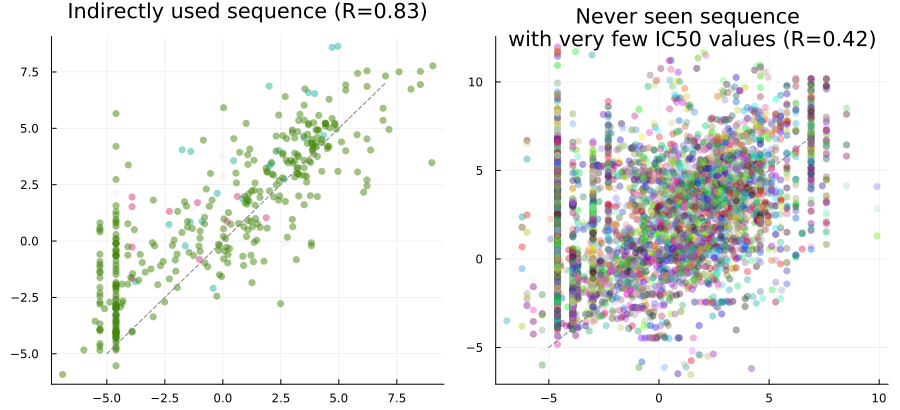

In [12]:
Plots.plot(p1, p2, layout=(1, 2), size=(900, 410) )